# Cluster shape in the windowed feature space

---
## 1. Setup

In [10]:
import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..") 

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NORMAL, ATTACK = C[0], "#d03b3b"
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})

PARTS = ("train", "validation", "test")
DATASETS = {
    "swat": ("../data/processed/swat", 60),
    "hai": ("../data/processed/hai", 30),
    "esa_rare_anomalies": ("../data/processed/esa_rare_anomalies", 600),
}
print("pandas", pd.__version__, "| matplotlib", mpl.__version__)

pandas 3.0.6 | matplotlib 3.11.2


### Windowing

In [11]:
def window_frame(df: pd.DataFrame, columns: list[str], seconds: int,
                 label: str, categorical: list[str]) -> tuple[pd.DataFrame, list[str]]:
    """Aggregate to fixed windows on absolute time, in one process.
    """
    numeric = [c for c in columns if c not in set(categorical)]
    epoch = df.index.astype("int64") // 10**9
    bucket = pd.Series((epoch // seconds) * seconds, index=df.index, name="_w")

    grouped = df.groupby(bucket, sort=True)
    mean = grouped[numeric].mean()
    std = grouped[numeric].std(ddof=0).fillna(0.0)

    cols: dict[str, pd.Series] = {}
    names: list[str] = []
    for c in numeric:
        cols[f"{c}_mean"] = mean[c]
        cols[f"{c}_std"] = std[c]
        names += [f"{c}_mean", f"{c}_std"]

    for c in categorical:
        counts = (df.groupby([bucket, df[c]], sort=True).size()
                    .rename("n").reset_index())
        counts.columns = ["_w", "_v", "n"]
        per = counts.groupby("_w").agg(
            total=("n", "sum"), top=("n", "max"), nunique=("n", "size"),
            nlogn=("n", lambda s: float((s * np.log(s)).sum())))
        entropy = np.log(per["total"]) - per["nlogn"] / per["total"]
        order = counts.sort_values(["_w", "n", "_v"], ascending=[True, False, True])
        mode = order.groupby("_w")["_v"].first()
        for key, values in (("mode", mode.astype("float64")),
                            ("entropy", entropy),
                            ("nunique", per["nunique"].astype("float64")),
                            ("maxprop", per["top"] / per["total"])):
            cols[f"{c}_{key}"] = values
            names.append(f"{c}_{key}")

    out = pd.DataFrame(cols)
    out[label] = grouped[label].max()
    out.insert(0, "datetime", pd.to_datetime(out.index, unit="s"))
    return out.reset_index(drop=True), names


def windowed(name: str, split_dir: str, seconds: int) -> dict[str, pd.DataFrame]:
    from dencast.utils import declared_categorical

    declared = set(declared_categorical(
        name.split("_")[0], Path("../data/raw/categorical_columns.yaml")))

    frames, built = {}, None
    for part in PARTS:
        hits = sorted(Path(split_dir).glob(f"*_{part}.parquet"))
        if len(hits) != 1:
            raise FileNotFoundError(f"{len(hits)} candidates for {part} in {split_dir}")
        raw = pd.read_parquet(hits[0])
        raw.index = pd.to_datetime(raw.index)
        label = next(c for c in raw.columns if c.startswith("is_") or c.startswith("label"))
        columns = [c for c in raw.columns
                   if not c.startswith(("is_", "label_")) and c != "datetime"]
        cat = [c for c in columns if c in declared]
        frames[part], built = window_frame(raw, columns, seconds, label, cat)
        print(f"  {name} {part:<11} {len(raw):>9,} rows -> {len(frames[part]):>7,} "
              f"windows x {len(built)} features ({len(columns) - len(cat)} numeric, "
              f"{len(cat)} categorical)")
    return frames


def scale_frames(frames: dict[str, pd.DataFrame],
                 skip: tuple[str, ...] = ("_mode",)) -> dict[str, pd.DataFrame]:
    out = {}
    cols = [c for c in frames["train"].columns
            if c != "datetime" and not c.startswith("is_") and not c.startswith("label")
            and not c.endswith(skip)]
    mean = frames["train"][cols].mean()
    std = frames["train"][cols].std(ddof=1).replace(0.0, 1.0)
    for part, f in frames.items():
        g = f.copy()
        g[cols] = (g[cols] - mean) / std
        out[part] = g
    return out


WIN = {name: scale_frames(windowed(name, d, s))
       for name, (d, s) in DATASETS.items()}

  swat train         496,800 rows ->   8,280 windows x 82 features (21 numeric, 10 categorical)
  swat validation    224,959 rows ->   3,750 windows x 82 features (21 numeric, 10 categorical)
  swat test          224,960 rows ->   3,751 windows x 82 features (21 numeric, 10 categorical)
  hai train         572,400 rows ->  19,082 windows x 114 features (53 numeric, 2 categorical)
  hai validation    115,200 rows ->   3,841 windows x 114 features (53 numeric, 2 categorical)
  hai test          115,200 rows ->   3,841 windows x 114 features (53 numeric, 2 categorical)
  esa_rare_anomalies train       2,602,493 rows ->  78,308 windows x 146 features (57 numeric, 8 categorical)
  esa_rare_anomalies validation    883,200 rows ->  26,496 windows x 146 features (57 numeric, 8 categorical)
  esa_rare_anomalies test        2,179,200 rows ->  65,376 windows x 146 features (57 numeric, 8 categorical)


---
## 2. How many directions does the data occupy?

In [12]:
from sklearn.decomposition import PCA

def project(frames: dict[str, pd.DataFrame], n_components: int = 10) -> dict:
    """Fit PCA on train, project every part into that space.
    """
    label = next(c for c in frames["train"].columns if c.startswith("is_") or c.startswith("label"))
    feats = [c for c in frames["train"].columns
             if c != "datetime" and not c.startswith("is_") and not c.startswith("label")]

    pca = PCA(n_components=min(n_components, len(feats))).fit(
        frames["train"][feats])

    coords, labels = {}, {}
    for p, f in frames.items():
        coords[p] = pca.transform(f[feats])
        labels[p] = (f[label].to_numpy() != 0).astype("uint8")
    return {"pca": pca, "features": feats,
            "coords": coords, "labels": labels, "label_column": label}


PCS = {name: project(frames) for name, frames in WIN.items()}

rows = []
for name, p in PCS.items():
    ev = p["pca"].explained_variance_ratio_
    cum = np.cumsum(ev)
    enough = int(np.searchsorted(cum, 0.90) + 1) if cum[-1] >= 0.90 else f"more than {len(ev)}"
    rows.append({
        "dataset": name,
        "features": len(p["features"]),
        "PC1": f"{ev[0]:.1%}",
        "PC1+PC2": f"{cum[1]:.1%}",
        "first 10": f"{cum[-1]:.1%}",
        "components for 90%": enough,
    })
print(pd.DataFrame(rows).to_string(index=False))

           dataset  features   PC1 PC1+PC2 first 10 components for 90%
              swat        82 14.6%   28.1%    74.5%       more than 10
               hai       114  8.2%   14.5%    49.6%       more than 10
esa_rare_anomalies       146  9.9%   16.3%    39.6%       more than 10


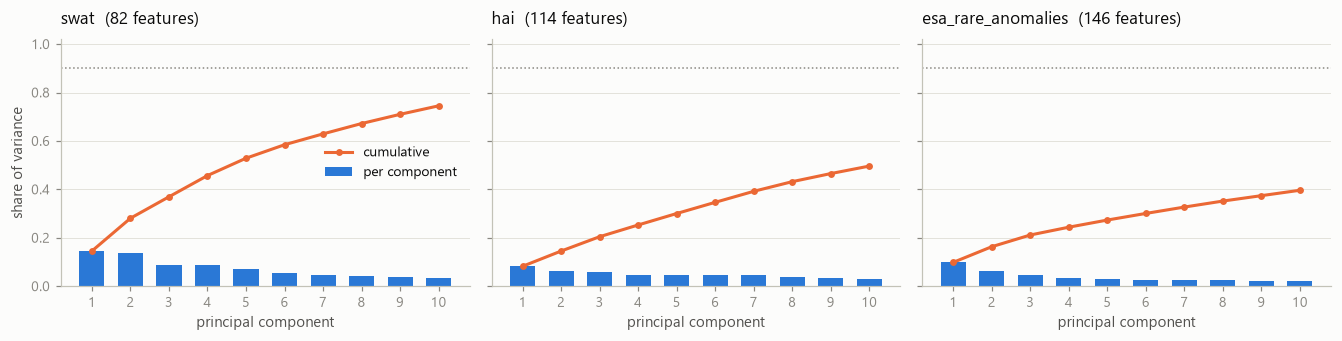

In [13]:
fig, axes = plt.subplots(1, len(PCS), figsize=(4.1 * len(PCS), 3.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, (name, p) in zip(axes, PCS.items()):
    ev = p["pca"].explained_variance_ratio_
    cum = np.cumsum(ev)
    x = np.arange(1, len(ev) + 1)
    ax.bar(x, ev, color=SEQ[7], width=0.65, label="per component")
    ax.plot(x, cum, color=C[1], marker="o", markersize=3.5, label="cumulative")
    ax.axhline(0.90, color=MUTED, linestyle=":", linewidth=1)
    ax.set(title=f"{name}  ({len(p['features'])} features)",
           xlabel="principal component", ylim=(0, 1.02), xticks=x)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("share of variance")
axes[0].legend(loc="center right")
fig.tight_layout()
plt.show()

---
## 3. The shape of normality, and where the anomalies fall

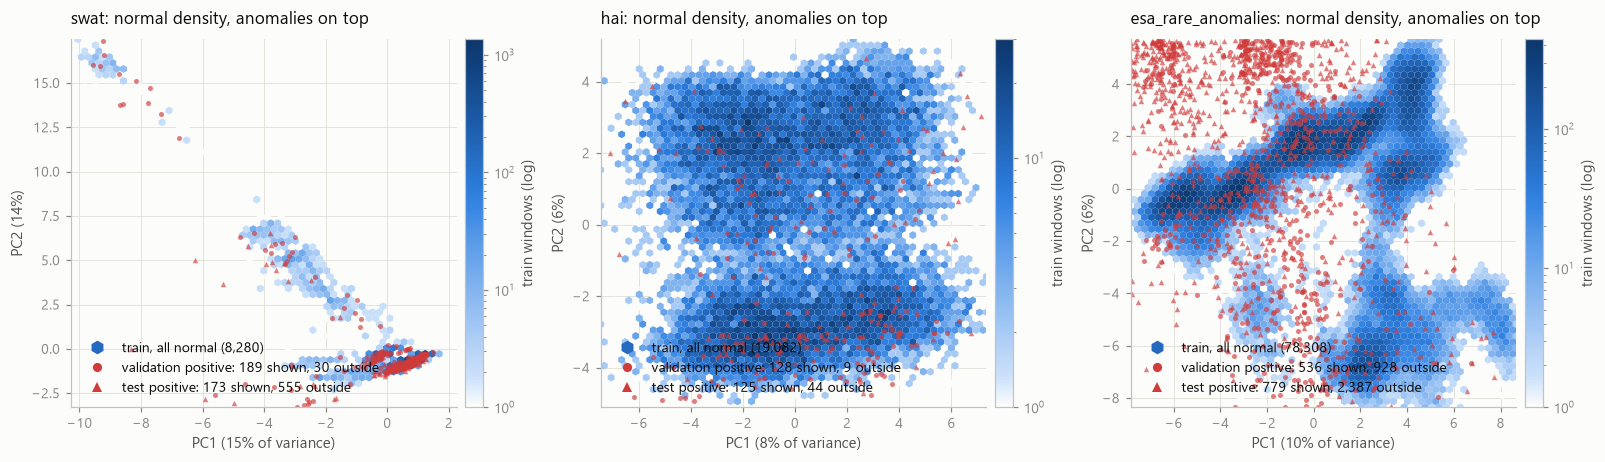

In [14]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, len(PCS), figsize=(4.9 * len(PCS), 4.3))
axes = np.atleast_1d(axes)
blues = mpl.colors.LinearSegmentedColormap.from_list("seq", [SURFACE] + SEQ)

for ax, (name, p) in zip(axes, PCS.items()):
    tr = p["coords"]["train"]

    lo, hi = np.percentile(tr[:, :2], [1, 99], axis=0)
    pad = 0.08 * (hi - lo)
    xlim, ylim = (lo[0] - pad[0], hi[0] + pad[0]), (lo[1] - pad[1], hi[1] + pad[1])

    hb = ax.hexbin(tr[:, 0], tr[:, 1], gridsize=55, bins="log", mincnt=1,
                   cmap=blues, linewidths=0, extent=(*xlim, *ylim))

    handles = [Line2D([], [], marker="h", linestyle="none", markersize=9,
                      markerfacecolor=SEQ[8], markeredgecolor="none",
                      label=f"train, all normal ({len(tr):,})")]
    for part, marker, size in (("validation", "o", 11), ("test", "^", 13)):
        pts = p["coords"][part][p["labels"][part] == 1]
        if not len(pts):
            continue
        seen = ((pts[:, 0] >= xlim[0]) & (pts[:, 0] <= xlim[1])
                & (pts[:, 1] >= ylim[0]) & (pts[:, 1] <= ylim[1]))
        ax.scatter(pts[seen, 0], pts[seen, 1], s=size, c=ATTACK, marker=marker,
                   linewidths=0, alpha=0.65)
        handles.append(Line2D([], [], marker=marker, linestyle="none", markersize=6,
                              markerfacecolor=ATTACK, markeredgecolor="none",
                              label=f"{part} positive: {int(seen.sum()):,} shown, "
                                    f"{int((~seen).sum()):,} outside"))

    ev = p["pca"].explained_variance_ratio_
    ax.set(xlim=xlim, ylim=ylim,
           title=f"{name}: normal density, anomalies on top",
           xlabel=f"PC1 ({ev[0]:.0%} of variance)",
           ylabel=f"PC2 ({ev[1]:.0%})")
    leg = ax.legend(handles=handles, loc="lower left", framealpha=0.92)
    leg.get_frame().set(facecolor=SURFACE, edgecolor=GRID, linewidth=0.6)
    fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.02, label="train windows (log)")

fig.tight_layout()
plt.show()

---
## 4. The training windows under t-SNE

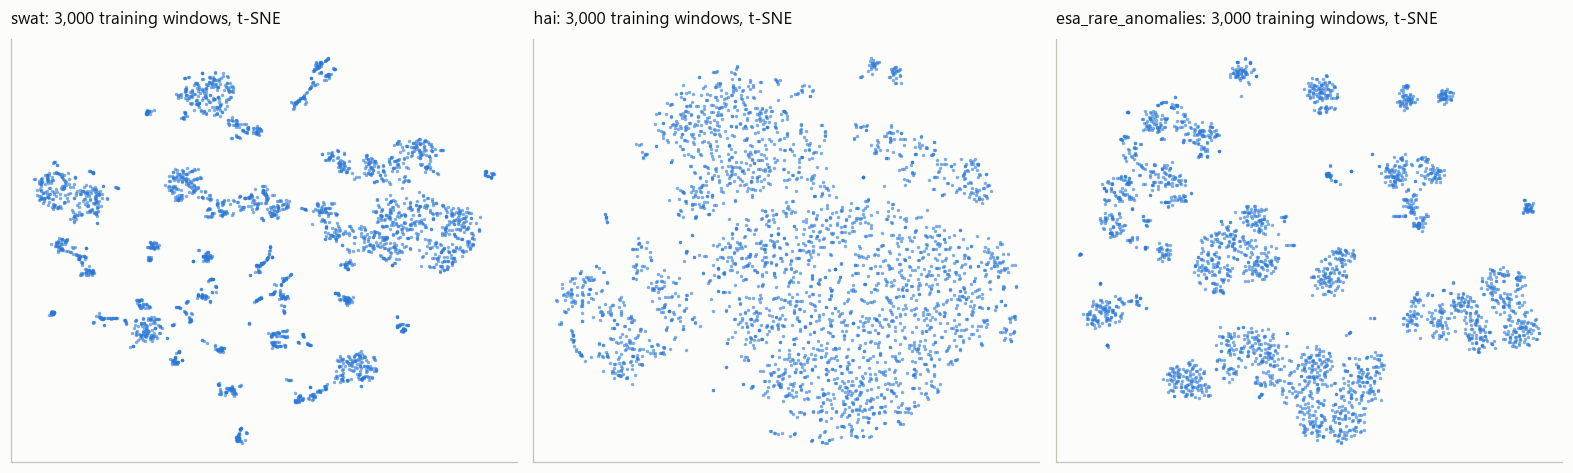

In [15]:
from sklearn.manifold import TSNE

TSNE_SAMPLE = 3000     

fig, axes = plt.subplots(1, len(WIN), figsize=(4.8 * len(WIN), 4.4))
axes = np.atleast_1d(axes)

for ax, (name, frames) in zip(axes, WIN.items()):
    feats = [c for c in frames["train"].columns
             if c != "datetime" and not c.startswith("is_") and not c.startswith("label")]
    X = frames["train"][feats].to_numpy("float64")
    rng = np.random.default_rng(42)
    take = (rng.choice(len(X), TSNE_SAMPLE, replace=False)
            if len(X) > TSNE_SAMPLE else np.arange(len(X)))
    emb = TSNE(n_components=2, perplexity=30, method="barnes_hut", init="random",
               random_state=42, max_iter=750).fit_transform(X[take])

    ax.scatter(emb[:, 0], emb[:, 1], s=5, c=C[0], linewidths=0, alpha=0.6)
    ax.set(title=f"{name}: {len(take):,} training windows, t-SNE",
           xticks=[], yticks=[])
    ax.grid(visible=False)

fig.tight_layout()
plt.show()